# TD6: Bubble Dynamics with Neural Operators

We're working with the Rayleigh-Plesset equation that governs bubble radius evolution in an incompressible fluid:

$$\frac{P_{\infty}(t)-P_{B}(t)}{\rho_L} = R\ddot{R} + \frac{3}{2}\dot{R}^2 + \frac{4\nu_L}{ R}\dot{R} + \frac{2\gamma}{\rho_L R}$$

The goal is to learn the operator that maps a pressure difference profile $\Delta P(t)$ to the resulting bubble radius trajectory $R(t)$. We'll compare three approaches: DeepONet, RNN, and FNO.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
import os, time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"PyTorch: {torch.__version__}")

Using device: cuda (NVIDIA GeForce RTX 4060 Ti)
PyTorch: 2.10.0+cu128


## Loading the data

We have two datasets generated from the Rayleigh-Plesset equation. The training set (`res_1000_1.npz`) uses initial bubble radius $R_0 = 1\text{mm}$, while the test set (`res_1000_08.npz`) uses $R_0 = 0.8\text{mm}$. Each contains 1500 simulations with different pressure profiles over the time interval $[0, 5 \times 10^{-4}]$ seconds.

In [2]:
train_dataset = np.load('res_1000_1.npz')
test_dataset = np.load('res_1000_08.npz')

print("Train dataset:")
for k in train_dataset.keys():
    print(f"  {k}: {train_dataset[k].shape}, dtype={train_dataset[k].dtype}")

print("\nTest dataset:")
for k in test_dataset.keys():
    print(f"  {k}: {test_dataset[k].shape}, dtype={test_dataset[k].dtype}")

t = train_dataset['t']
print(f"\nTime range: [{t.min():.2e}, {t.max():.2e}] seconds")

Train dataset:
  del_p: (1500, 1000), dtype=float64
  t: (1000,), dtype=float64
  R: (1500, 1000), dtype=float64

Test dataset:
  del_p: (1500, 1000), dtype=float64
  t: (1000,), dtype=float64
  R: (1500, 1000), dtype=float64

Time range: [0.00e+00, 5.00e-04] seconds


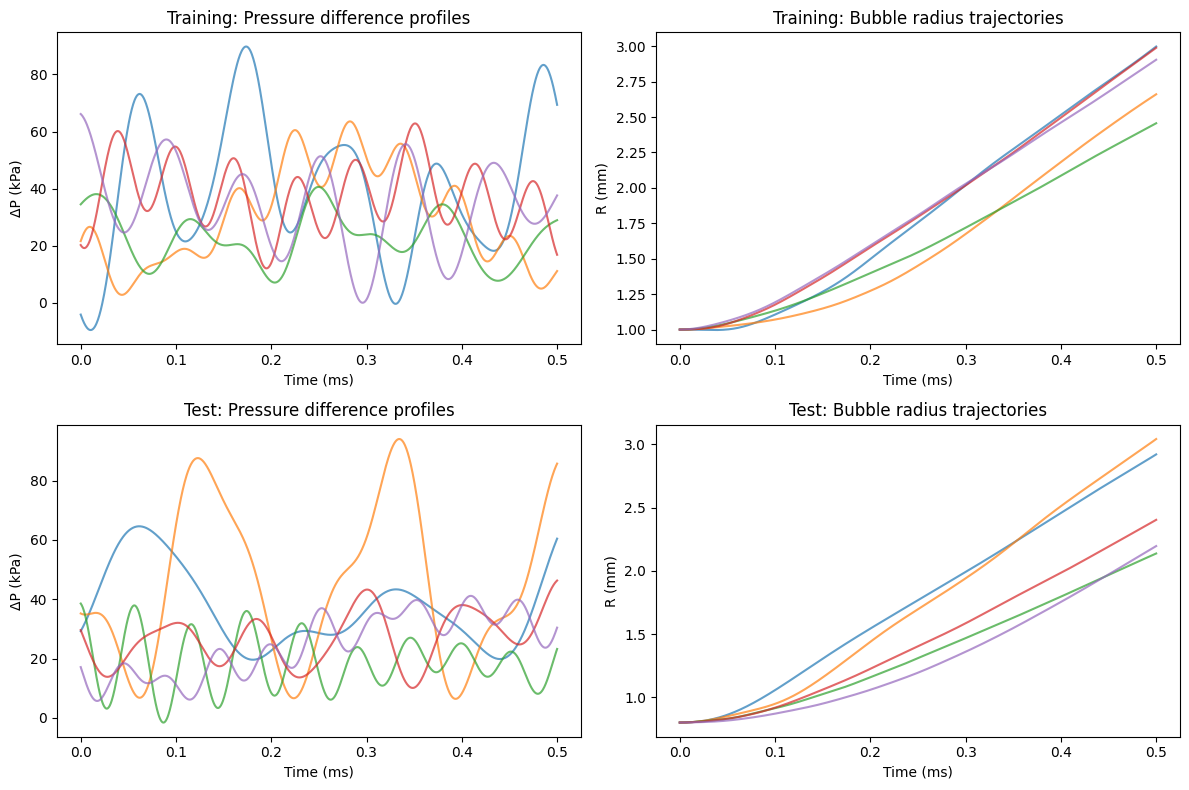

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

t_ms = t * 1e3  # convert to milliseconds for readability

# Plot a few training samples
for i in range(5):
    axes[0, 0].plot(t_ms, train_dataset['del_p'][i] / 1e3, alpha=0.7)
axes[0, 0].set_xlabel('Time (ms)'); axes[0, 0].set_ylabel('ΔP (kPa)')
axes[0, 0].set_title('Training: Pressure difference profiles')

for i in range(5):
    axes[0, 1].plot(t_ms, train_dataset['R'][i] * 1e3, alpha=0.7)
axes[0, 1].set_xlabel('Time (ms)'); axes[0, 1].set_ylabel('R (mm)')
axes[0, 1].set_title('Training: Bubble radius trajectories')

# Same for test
for i in range(5):
    axes[1, 0].plot(t_ms, test_dataset['del_p'][i] / 1e3, alpha=0.7)
axes[1, 0].set_xlabel('Time (ms)'); axes[1, 0].set_ylabel('ΔP (kPa)')
axes[1, 0].set_title('Test: Pressure difference profiles')

for i in range(5):
    axes[1, 1].plot(t_ms, test_dataset['R'][i] * 1e3, alpha=0.7)
axes[1, 1].set_xlabel('Time (ms)'); axes[1, 1].set_ylabel('R (mm)')
axes[1, 1].set_title('Test: Bubble radius trajectories')

plt.tight_layout()
plt.show()

The pressure profiles are random superpositions of sinusoidal modes in the 10-50 kPa range, giving diverse forcing conditions. The resulting radius trajectories show the bubble oscillating around its equilibrium size. Notice that training samples start at $R_0 = 1\text{mm}$ while test samples start at $R_0 = 0.8\text{mm}$, so the model needs to generalize to a different initial condition regime.

## Preprocessing

We use the functions from `bubble.py` to prepare the data. The `preprocess` function re-samples each pressure/radius trajectory onto a chosen number of grid points via cubic interpolation. The branch network input gets `m` pressure values and the trunk network input gets `npoints_output` time locations. Normalization is done with global mean/std for the pressure and radius values.

In [4]:
def preprocess(dataset, m, npoints_output, is_test=False):
    """Re-sample pressure and radius onto uniform grids for branch and trunk inputs."""
    p = dataset['del_p']
    t = dataset['t']
    r = dataset['R']
    
    P = interp1d(t, p, kind='cubic')
    R = interp1d(t, r, kind='cubic')
    
    t_min, t_max = 0, 5e-4
    
    X_func = P(np.linspace(t_min, t_max, m))     # (N_samples, m)
    X_loc  = np.linspace(t_min, t_max, npoints_output)[:, None]  # (npoints_output, 1)
    y      = R(np.ravel(X_loc))                    # (N_samples, npoints_output)
    
    if is_test:
        X_func = X_func[:50]
        y = y[:50]
    
    return X_func, X_loc, y

def normalize(X_func, X_loc, y, Par):
    """Normalize inputs and outputs using precomputed statistics."""
    X_func = (X_func - Par['p_mean']) / Par['p_std']
    X_loc  = (X_loc - np.min(X_loc)) / (np.max(X_loc) - np.min(X_loc))
    y = (y - Par['r_mean']) / Par['r_std']
    return X_func.astype(np.float32), X_loc.astype(np.float32), y.astype(np.float32)

# Preprocess with m=200 branch points and 500 output time points
m = 200
npoints_output = 500

X_func_train, X_loc_train, y_train = preprocess(train_dataset, m, npoints_output)
X_func_test, X_loc_test, y_test = preprocess(test_dataset, m, npoints_output, is_test=True)

Par = {
    'p_mean': np.mean(X_func_train),
    'p_std':  np.std(X_func_train),
    'r_mean': np.mean(y_train),
    'r_std':  np.std(y_train),
}

X_func_train, X_loc_train, y_train = normalize(X_func_train, X_loc_train, y_train, Par)
X_func_test, X_loc_test, y_test    = normalize(X_func_test, X_loc_test, y_test, Par)

print(f"X_func_train: {X_func_train.shape}  (branch input: {X_func_train.shape[0]} samples, {X_func_train.shape[1]} pressure values)")
print(f"X_loc_train:  {X_loc_train.shape}  (trunk input: {X_loc_train.shape[0]} time points)")
print(f"y_train:      {y_train.shape}  (target: {y_train.shape[0]} samples, {y_train.shape[1]} radius values)")
print(f"\nX_func_test:  {X_func_test.shape}")
print(f"y_test:       {y_test.shape}")

X_func_train: (1500, 200)  (branch input: 1500 samples, 200 pressure values)
X_loc_train:  (500, 1)  (trunk input: 500 time points)
y_train:      (1500, 500)  (target: 1500 samples, 500 radius values)

X_func_test:  (50, 200)
y_test:       (50, 500)


## Question 1: DeepONet

A DeepONet has two sub-networks. The **branch network** takes the input function (here the pressure profile, discretized at `m` sensor locations) and produces a latent representation of size `p`. The **trunk network** takes the evaluation location (here the time $t$) and also produces a vector of size `p`. The output is their dot product:

$$G_\theta(u)(t) = \sum_{k=1}^{p} b_k(u) \cdot \tau_k(t) + b_0$$

where $b_k$ comes from the branch and $\tau_k$ from the trunk.

In [5]:
class DeepONet(nn.Module):
    def __init__(self, branch_input_dim, trunk_input_dim=1, hidden_dim=128, latent_dim=64, n_layers=4):
        super().__init__()
        
        # Branch network: pressure profile -> latent
        branch_layers = [nn.Linear(branch_input_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            branch_layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        branch_layers.append(nn.Linear(hidden_dim, latent_dim))
        self.branch = nn.Sequential(*branch_layers)
        
        # Trunk network: time location -> latent
        trunk_layers = [nn.Linear(trunk_input_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            trunk_layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        trunk_layers.append(nn.Linear(hidden_dim, latent_dim))
        self.trunk = nn.Sequential(*trunk_layers)
        
        self.bias = nn.Parameter(torch.zeros(1))
    
    def forward(self, x_func, x_loc):
        """
        x_func: (batch, m)       -- branch input (pressure profile)
        x_loc:  (n_points, 1)    -- trunk input (time locations)
        Returns: (batch, n_points)
        """
        b = self.branch(x_func)   # (batch, latent_dim)
        t = self.trunk(x_loc)     # (n_points, latent_dim)
        # Dot product: (batch, latent_dim) @ (latent_dim, n_points) -> (batch, n_points)
        out = torch.mm(b, t.T) + self.bias
        return out

# Quick test
model_don = DeepONet(branch_input_dim=m, hidden_dim=128, latent_dim=64).to(device)
total_params = sum(p.numel() for p in model_don.parameters())
print(f"DeepONet parameters: {total_params:,}")

# Test forward pass
x_f = torch.randn(4, m).to(device)
x_l = torch.randn(500, 1).to(device)
out = model_don(x_f, x_l)
print(f"Forward pass: input ({x_f.shape}, {x_l.shape}) -> output {out.shape}")

DeepONet parameters: 141,569
Forward pass: input (torch.Size([4, 200]), torch.Size([500, 1])) -> output torch.Size([4, 500])


In [6]:
def train_deeponet(model, X_func_train, X_loc_train, y_train, X_func_test, X_loc_test, y_test,
                    epochs=2000, lr=1e-3, batch_size=256, log_every=200):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    
    X_f = torch.tensor(X_func_train, dtype=torch.float32).to(device)
    X_l = torch.tensor(X_loc_train, dtype=torch.float32).to(device)
    Y   = torch.tensor(y_train, dtype=torch.float32).to(device)
    
    X_f_test = torch.tensor(X_func_test, dtype=torch.float32).to(device)
    X_l_test = torch.tensor(X_loc_test, dtype=torch.float32).to(device)
    Y_test   = torch.tensor(y_test, dtype=torch.float32).to(device)
    
    n_samples = X_f.shape[0]
    history = {'train_loss': [], 'test_loss': []}
    
    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n_samples, device=device)
        epoch_loss = 0.0
        n_batches = 0
        
        for i in range(0, n_samples, batch_size):
            idx = perm[i:i+batch_size]
            pred = model(X_f[idx], X_l)
            loss = nn.functional.mse_loss(pred, Y[idx])
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        
        scheduler.step()
        epoch_loss /= n_batches
        history['train_loss'].append(epoch_loss)
        
        if epoch % log_every == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                pred_test = model(X_f_test, X_l_test)
                test_loss = nn.functional.mse_loss(pred_test, Y_test).item()
            history['test_loss'].append(test_loss)
            elapsed = time.time() - t0
            print(f"  epoch {epoch:5d} | train_loss={epoch_loss:.4e} | test_loss={test_loss:.4e} | {elapsed:.1f}s")
    
    return history

print("Training function defined.")

Training function defined.


Let's train the DeepONet for 2000 epochs and see how it does. I'll cache the trained model to avoid retraining if we come back to this cell.

In [7]:
DON_CACHE = 'deeponet_checkpoint.pt'

if os.path.exists(DON_CACHE):
    print("Loading cached DeepONet...")
    checkpoint = torch.load(DON_CACHE, map_location=device, weights_only=True)
    model_don = DeepONet(branch_input_dim=m, hidden_dim=128, latent_dim=64).to(device)
    model_don.load_state_dict(checkpoint['model_state'])
    don_history = checkpoint['history']
    print(f"Loaded. Final train loss: {don_history['train_loss'][-1]:.4e}")
else:
    print("Training DeepONet from scratch...")
    model_don = DeepONet(branch_input_dim=m, hidden_dim=128, latent_dim=64).to(device)
    don_history = train_deeponet(
        model_don, X_func_train, X_loc_train, y_train,
        X_func_test, X_loc_test, y_test,
        epochs=2000, lr=1e-3, batch_size=256, log_every=400
    )
    torch.save({'model_state': model_don.state_dict(), 'history': don_history}, DON_CACHE)
    print("Saved checkpoint.")

Loading cached DeepONet...
Loaded. Final train loss: 3.2714e-05


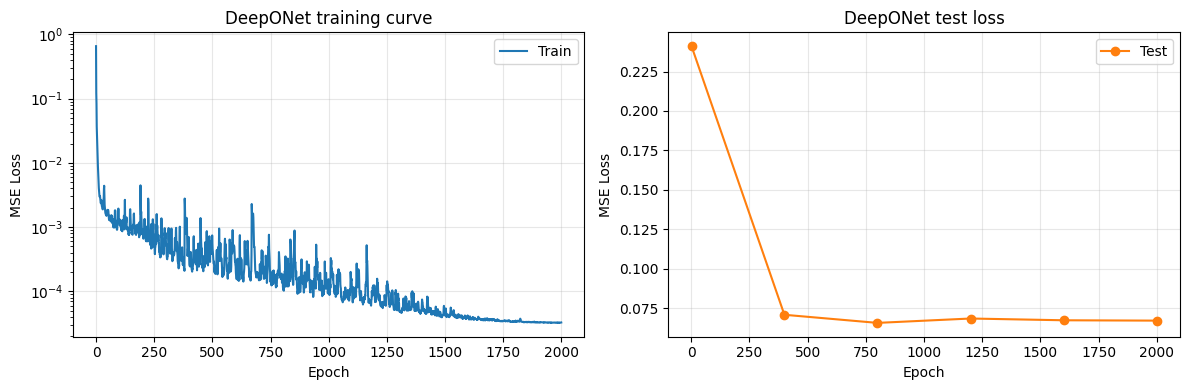

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(don_history['train_loss'], label='Train')
axes[0].set_yscale('log')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('DeepONet training curve')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Test loss was logged every 400 epochs
test_epochs = [1] + list(range(400, 2001, 400))
axes[1].plot(test_epochs, don_history['test_loss'], 'o-', color='tab:orange', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE Loss')
axes[1].set_title('DeepONet test loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

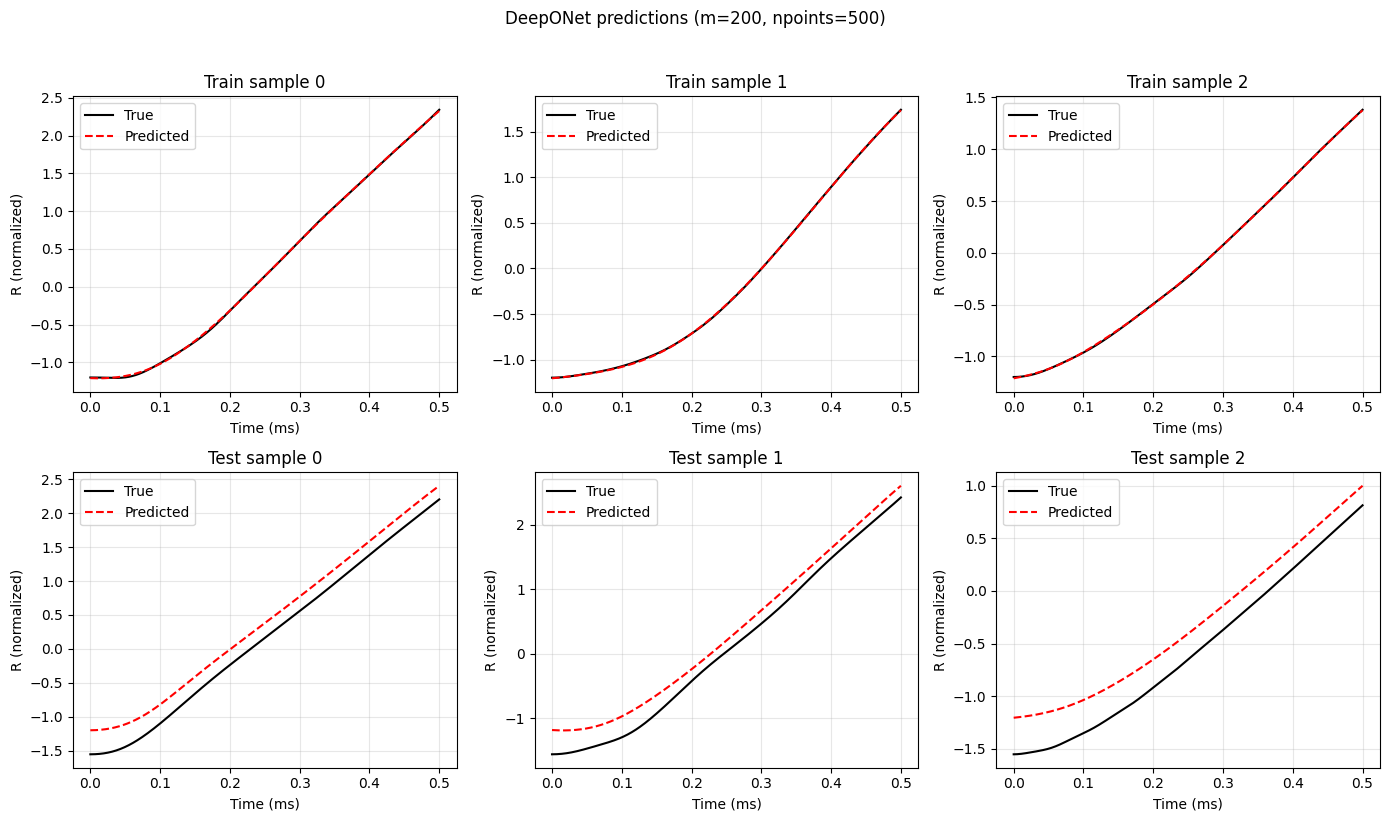

Train MSE: 3.2426e-05, relative L1 error: 0.0049
Test  MSE: 6.7071e-02, relative L1 error: 0.2788


In [9]:
model_don.eval()
X_l_t = torch.tensor(X_loc_train, dtype=torch.float32).to(device)

# Predictions on train and test
with torch.no_grad():
    pred_train = model_don(torch.tensor(X_func_train, dtype=torch.float32).to(device), X_l_t).cpu().numpy()
    X_l_te = torch.tensor(X_loc_test, dtype=torch.float32).to(device)
    pred_test = model_don(torch.tensor(X_func_test, dtype=torch.float32).to(device), X_l_te).cpu().numpy()

t_plot = np.linspace(0, 5e-4, npoints_output) * 1e3  # ms

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i in range(3):
    axes[0, i].plot(t_plot, y_train[i], 'k-', label='True', linewidth=1.5)
    axes[0, i].plot(t_plot, pred_train[i], 'r--', label='Predicted', linewidth=1.5)
    axes[0, i].set_title(f'Train sample {i}')
    axes[0, i].set_xlabel('Time (ms)'); axes[0, i].set_ylabel('R (normalized)')
    axes[0, i].legend(); axes[0, i].grid(True, alpha=0.3)

for i in range(3):
    axes[1, i].plot(t_plot, y_test[i], 'k-', label='True', linewidth=1.5)
    axes[1, i].plot(t_plot, pred_test[i], 'r--', label='Predicted', linewidth=1.5)
    axes[1, i].set_title(f'Test sample {i}')
    axes[1, i].set_xlabel('Time (ms)'); axes[1, i].set_ylabel('R (normalized)')
    axes[1, i].legend(); axes[1, i].grid(True, alpha=0.3)

plt.suptitle('DeepONet predictions (m=200, npoints=500)', y=1.02)
plt.tight_layout()
plt.show()

# Quantitative metrics
train_mse = np.mean((pred_train - y_train)**2)
test_mse  = np.mean((pred_test - y_test)**2)
train_rel = np.mean(np.abs(pred_train - y_train)) / np.mean(np.abs(y_train))
test_rel  = np.mean(np.abs(pred_test - y_test)) / np.mean(np.abs(y_test))
print(f"Train MSE: {train_mse:.4e}, relative L1 error: {train_rel:.4f}")
print(f"Test  MSE: {test_mse:.4e}, relative L1 error: {test_rel:.4f}")

The DeepONet fits the training data very well (relative error below 0.5%), but the test error is significantly higher (~28%). This is expected since the test set uses a different initial bubble radius ($R_0 = 0.8\text{mm}$ vs $1\text{mm}$ in training), so the model needs to generalize to unseen physical regimes. The overall shape is captured, but there's a noticeable offset, which is the hallmark of distribution shift.

## Question 2: Effect of Discretization and RNN Comparison

Let's explore how the number of branch sensors (`m`) and trunk output points (`npoints_output`) affects the DeepONet performance. We'll try sparse and dense discretizations, then compare against an RNN baseline.

### 2a. Varying branch discretization (m)

We fix the trunk output to 500 points and vary the number of branch sensor points: m = 20 (very sparse), 50, 200 (our baseline), and 500 (dense). A sparser branch means the model sees a coarser approximation of the pressure profile.

In [10]:
branch_configs = [20, 50, 200, 500]
npts_out = 500
branch_results = {}

BRANCH_CACHE = 'branch_study_checkpoint.pt'

if os.path.exists(BRANCH_CACHE):
    print("Loading cached branch study results...")
    branch_results = torch.load(BRANCH_CACHE, map_location='cpu', weights_only=False)
else:
    for m_val in branch_configs:
        print(f"\n--- m={m_val} ---")
        Xf_tr, Xl_tr, y_tr = preprocess(train_dataset, m_val, npts_out)
        Xf_te, Xl_te, y_te = preprocess(test_dataset, m_val, npts_out, is_test=True)
        
        par = {
            'p_mean': np.mean(Xf_tr), 'p_std': np.std(Xf_tr),
            'r_mean': np.mean(y_tr), 'r_std': np.std(y_tr),
        }
        Xf_tr, Xl_tr, y_tr = normalize(Xf_tr, Xl_tr, y_tr, par)
        Xf_te, Xl_te, y_te = normalize(Xf_te, Xl_te, y_te, par)
        
        model = DeepONet(branch_input_dim=m_val, hidden_dim=128, latent_dim=64).to(device)
        hist = train_deeponet(model, Xf_tr, Xl_tr, y_tr, Xf_te, Xl_te, y_te,
                              epochs=1500, lr=1e-3, batch_size=256, log_every=500)
        
        model.eval()
        with torch.no_grad():
            Xl_t = torch.tensor(Xl_te, dtype=torch.float32).to(device)
            pred = model(torch.tensor(Xf_te, dtype=torch.float32).to(device), Xl_t).cpu().numpy()
        
        test_mse = np.mean((pred - y_te)**2)
        train_mse = hist['train_loss'][-1]
        branch_results[m_val] = {
            'train_mse': train_mse, 'test_mse': test_mse,
            'history': hist, 'pred': pred, 'y_test': y_te, 'X_loc': Xl_te
        }
        print(f"  Final: train_mse={train_mse:.4e}, test_mse={test_mse:.4e}")
    
    torch.save(branch_results, BRANCH_CACHE)
    print("\nSaved branch study results.")

Loading cached branch study results...


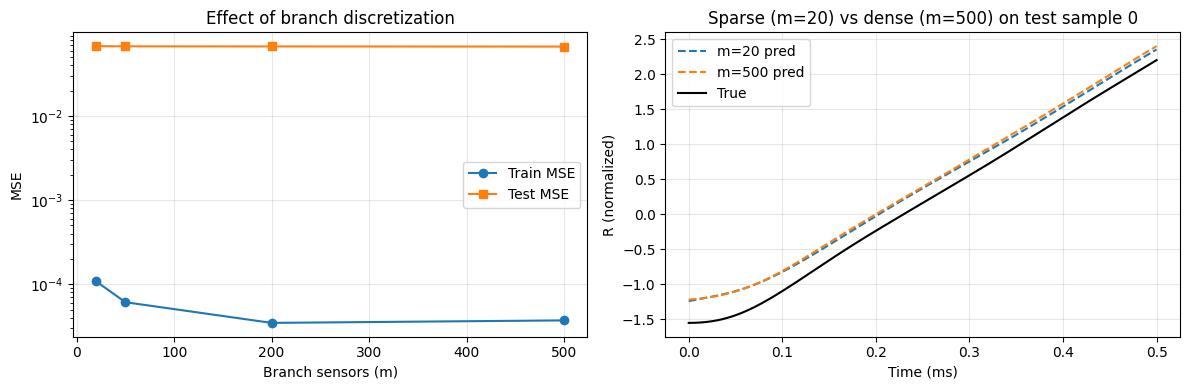

Branch discretization summary:
  m=  20: train_mse=1.08e-04, test_mse=6.76e-02
  m=  50: train_mse=6.11e-05, test_mse=6.73e-02
  m= 200: train_mse=3.47e-05, test_mse=6.71e-02
  m= 500: train_mse=3.71e-05, test_mse=6.68e-02


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

m_vals = sorted(branch_results.keys())
train_mses = [branch_results[m_v]['train_mse'] for m_v in m_vals]
test_mses = [branch_results[m_v]['test_mse'] for m_v in m_vals]

axes[0].plot(m_vals, train_mses, 'o-', label='Train MSE')
axes[0].plot(m_vals, test_mses, 's-', label='Test MSE')
axes[0].set_xlabel('Branch sensors (m)'); axes[0].set_ylabel('MSE')
axes[0].set_yscale('log'); axes[0].legend()
axes[0].set_title('Effect of branch discretization')
axes[0].grid(True, alpha=0.3)

# Show predictions for sparse vs dense on same test sample
t_plot = np.linspace(0, 5e-4, npts_out) * 1e3
for m_v in [20, 500]:
    axes[1].plot(t_plot, branch_results[m_v]['pred'][0], '--', label=f'm={m_v} pred', linewidth=1.5)
axes[1].plot(t_plot, branch_results[20]['y_test'][0], 'k-', label='True', linewidth=1.5)
axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('R (normalized)')
axes[1].set_title('Sparse (m=20) vs dense (m=500) on test sample 0')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Branch discretization summary:")
for m_v in m_vals:
    print(f"  m={m_v:4d}: train_mse={branch_results[m_v]['train_mse']:.2e}, test_mse={branch_results[m_v]['test_mse']:.2e}")

The branch discretization has a clear effect on training accuracy: going from m=20 (1.08e-4) to m=50 (6.11e-5) to m=200 (3.47e-5) steadily improves the training fit as the model receives a richer representation of the pressure profile. Interestingly, m=500 (3.71e-5) does not improve over m=200, suggesting diminishing returns once the pressure signal is well-resolved. The test MSE, however, is nearly identical across all choices (0.067 to 0.068), meaning the generalization gap is dominated by the distribution shift between train and test (different $R_0$), not by the input resolution. Even just 20 sensor points capture the pressure profile well enough for this smooth signal.

### 2b. Varying trunk discretization (npoints_output)

Now let's fix m=200 and vary the number of output time points: 50 (very sparse), 100, 500 (baseline), 800 (dense).

In [12]:
trunk_configs = [50, 100, 500, 800]
m_fixed = 200
trunk_results = {}

TRUNK_CACHE = 'trunk_study_checkpoint.pt'

if os.path.exists(TRUNK_CACHE):
    print("Loading cached trunk study results...")
    trunk_results = torch.load(TRUNK_CACHE, map_location='cpu', weights_only=False)
else:
    for npts in trunk_configs:
        print(f"\n--- npoints_output={npts} ---")
        Xf_tr, Xl_tr, y_tr = preprocess(train_dataset, m_fixed, npts)
        Xf_te, Xl_te, y_te = preprocess(test_dataset, m_fixed, npts, is_test=True)
        
        par = {
            'p_mean': np.mean(Xf_tr), 'p_std': np.std(Xf_tr),
            'r_mean': np.mean(y_tr), 'r_std': np.std(y_tr),
        }
        Xf_tr, Xl_tr, y_tr = normalize(Xf_tr, Xl_tr, y_tr, par)
        Xf_te, Xl_te, y_te = normalize(Xf_te, Xl_te, y_te, par)
        
        model = DeepONet(branch_input_dim=m_fixed, hidden_dim=128, latent_dim=64).to(device)
        hist = train_deeponet(model, Xf_tr, Xl_tr, y_tr, Xf_te, Xl_te, y_te,
                              epochs=1500, lr=1e-3, batch_size=256, log_every=500)
        
        model.eval()
        with torch.no_grad():
            Xl_t = torch.tensor(Xl_te, dtype=torch.float32).to(device)
            pred = model(torch.tensor(Xf_te, dtype=torch.float32).to(device), Xl_t).cpu().numpy()
        
        test_mse = np.mean((pred - y_te)**2)
        trunk_results[npts] = {
            'train_mse': hist['train_loss'][-1], 'test_mse': test_mse,
            'history': hist, 'pred': pred, 'y_test': y_te
        }
        print(f"  Final: train_mse={hist['train_loss'][-1]:.4e}, test_mse={test_mse:.4e}")
    
    torch.save(trunk_results, TRUNK_CACHE)
    print("\nSaved trunk study results.")

Loading cached trunk study results...


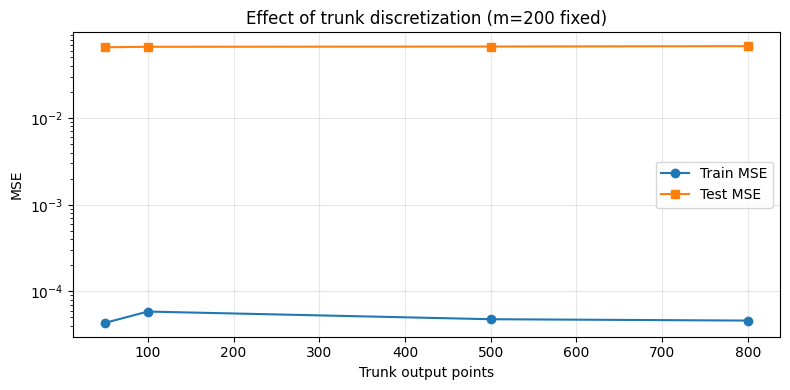

Trunk discretization summary:
  npts=  50: train_mse=4.33e-05, test_mse=6.55e-02
  npts= 100: train_mse=5.85e-05, test_mse=6.64e-02
  npts= 500: train_mse=4.78e-05, test_mse=6.68e-02
  npts= 800: train_mse=4.61e-05, test_mse=6.75e-02


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

npts_vals = sorted(trunk_results.keys())
train_mses = [trunk_results[n]['train_mse'] for n in npts_vals]
test_mses = [trunk_results[n]['test_mse'] for n in npts_vals]

ax.plot(npts_vals, train_mses, 'o-', label='Train MSE')
ax.plot(npts_vals, test_mses, 's-', label='Test MSE')
ax.set_xlabel('Trunk output points'); ax.set_ylabel('MSE')
ax.set_yscale('log'); ax.legend()
ax.set_title('Effect of trunk discretization (m=200 fixed)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Trunk discretization summary:")
for n in npts_vals:
    print(f"  npts={n:4d}: train_mse={trunk_results[n]['train_mse']:.2e}, test_mse={trunk_results[n]['test_mse']:.2e}")

Same story as with the branch: the trunk discretization barely affects performance. The training MSE stays in a narrow band (4.3e-5 to 5.9e-5) regardless of how many output points we use, meaning the trunk network learns the temporal mapping equally well at any resolution. The test error ranges from 0.065 to 0.068, again showing that the generalization gap from the distribution shift is the dominant factor, not the output resolution.

### 2c. RNN baseline

For comparison, let's train a GRU-based sequence-to-sequence model. The RNN takes the pressure profile as a sequence and outputs the radius at each time step. This is a fundamentally different approach: instead of learning an operator through branch/trunk decomposition, the RNN processes the input sequentially.

In [14]:
class BubbleRNN(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, n_layers=2, output_len=500):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers=n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
        self.output_len = output_len
    
    def forward(self, x):
        """
        x: (batch, seq_len, 1) pressure sequence
        Returns: (batch, output_len)
        """
        out, _ = self.gru(x)           # (batch, seq_len, hidden_dim)
        # Take output at evenly spaced positions to match desired output length
        seq_len = out.shape[1]
        indices = torch.linspace(0, seq_len - 1, self.output_len).long().to(x.device)
        out_sampled = out[:, indices, :]  # (batch, output_len, hidden_dim)
        pred = self.fc(out_sampled).squeeze(-1)  # (batch, output_len)
        return pred

# For the RNN we need to reformat the data: pressure as a sequence input
# We'll use the same m=200 discretization for fair comparison
rnn_m = 200

Xf_tr, Xl_tr, y_tr_rnn = preprocess(train_dataset, rnn_m, npoints_output)
Xf_te, Xl_te, y_te_rnn = preprocess(test_dataset, rnn_m, npoints_output, is_test=True)

par_rnn = {
    'p_mean': np.mean(Xf_tr), 'p_std': np.std(Xf_tr),
    'r_mean': np.mean(y_tr_rnn), 'r_std': np.std(y_tr_rnn),
}
Xf_tr, _, y_tr_rnn = normalize(Xf_tr, Xl_tr, y_tr_rnn, par_rnn)
Xf_te, _, y_te_rnn = normalize(Xf_te, Xl_te, y_te_rnn, par_rnn)

# Reshape pressure for RNN: (N, m) -> (N, m, 1)
Xf_tr_rnn = Xf_tr[:, :, None]
Xf_te_rnn = Xf_te[:, :, None]

model_rnn = BubbleRNN(input_dim=1, hidden_dim=128, n_layers=2, output_len=npoints_output).to(device)
total_params = sum(p.numel() for p in model_rnn.parameters())
print(f"RNN parameters: {total_params:,}")

# Quick forward pass test
test_in = torch.randn(4, rnn_m, 1).to(device)
test_out = model_rnn(test_in)
print(f"Forward pass: {test_in.shape} -> {test_out.shape}")

RNN parameters: 149,505
Forward pass: torch.Size([4, 200, 1]) -> torch.Size([4, 500])


In [15]:
RNN_CACHE = 'rnn_checkpoint.pt'

def train_rnn(model, X_train, y_train, X_test, y_test,
              epochs=2000, lr=1e-3, batch_size=64, log_every=400):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    
    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    Y_tr = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_te = torch.tensor(X_test, dtype=torch.float32).to(device)
    Y_te = torch.tensor(y_test, dtype=torch.float32).to(device)
    
    n = X_tr.shape[0]
    history = {'train_loss': [], 'test_loss': []}
    t0 = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=device)
        epoch_loss = 0.0
        n_batches = 0
        
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            pred = model(X_tr[idx])
            loss = nn.functional.mse_loss(pred, Y_tr[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        
        scheduler.step()
        epoch_loss /= n_batches
        history['train_loss'].append(epoch_loss)
        
        if epoch % log_every == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                pred_test = model(X_te)
                test_loss = nn.functional.mse_loss(pred_test, Y_te).item()
            history['test_loss'].append(test_loss)
            print(f"  epoch {epoch:5d} | train_loss={epoch_loss:.4e} | test_loss={test_loss:.4e} | {time.time()-t0:.1f}s")
    
    return history

if os.path.exists(RNN_CACHE):
    print("Loading cached RNN...")
    ckpt = torch.load(RNN_CACHE, map_location=device, weights_only=True)
    model_rnn = BubbleRNN(input_dim=1, hidden_dim=128, n_layers=2, output_len=npoints_output).to(device)
    model_rnn.load_state_dict(ckpt['model_state'])
    rnn_history = ckpt['history']
    print(f"Loaded. Final train loss: {rnn_history['train_loss'][-1]:.4e}")
else:
    print("Training RNN...")
    model_rnn = BubbleRNN(input_dim=1, hidden_dim=128, n_layers=2, output_len=npoints_output).to(device)
    rnn_history = train_rnn(model_rnn, Xf_tr_rnn, y_tr_rnn, Xf_te_rnn, y_te_rnn,
                            epochs=2000, lr=1e-3, batch_size=64, log_every=400)
    torch.save({'model_state': model_rnn.state_dict(), 'history': rnn_history}, RNN_CACHE)
    print("Saved RNN checkpoint.")

Loading cached RNN...
Loaded. Final train loss: 2.0837e-05


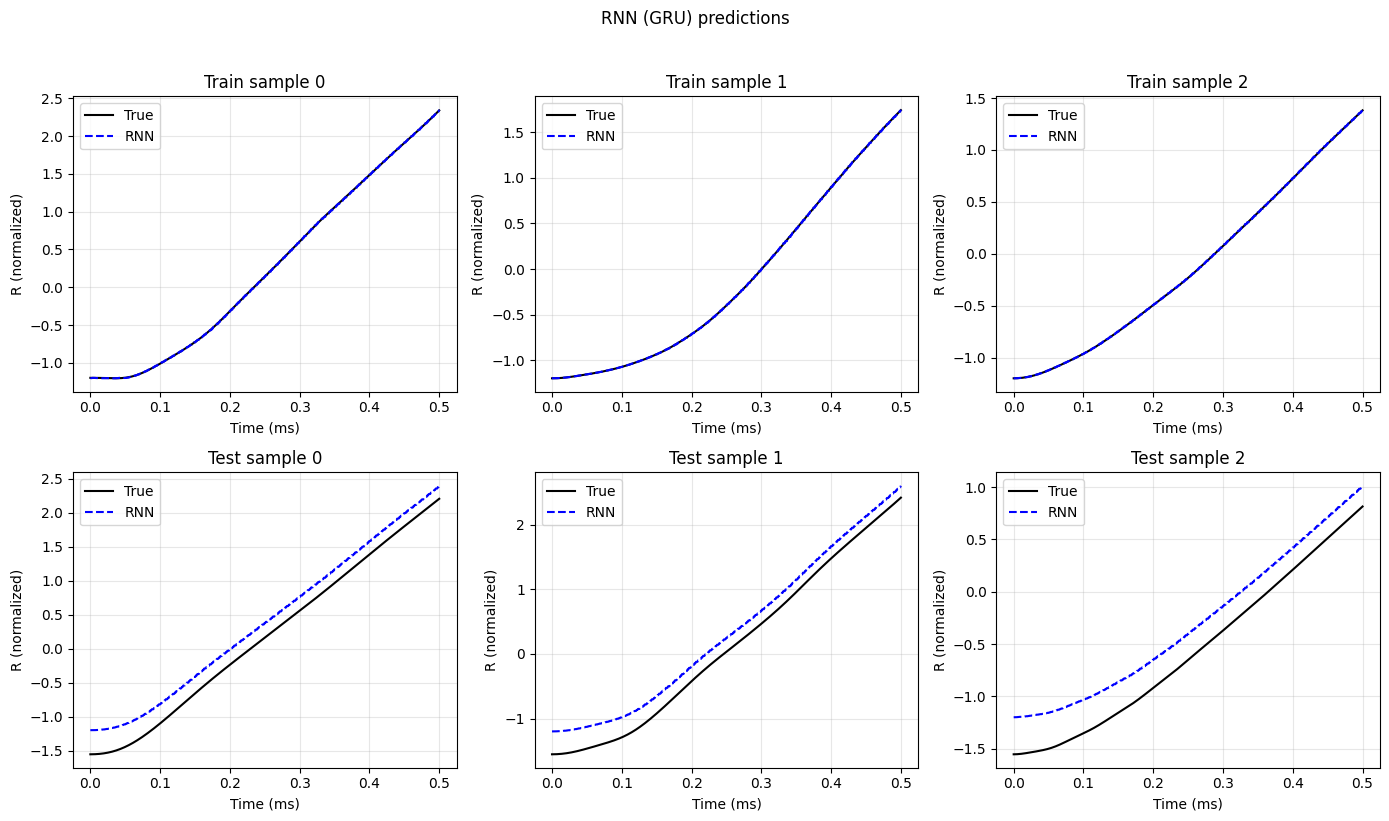

RNN   - Train MSE: 2.0918e-05, Test MSE: 6.7388e-02
DONet - Train MSE: 3.2426e-05, Test MSE: 6.7071e-02


In [16]:
model_rnn.eval()
with torch.no_grad():
    rnn_pred_train = model_rnn(torch.tensor(Xf_tr_rnn, dtype=torch.float32).to(device)).cpu().numpy()
    rnn_pred_test  = model_rnn(torch.tensor(Xf_te_rnn, dtype=torch.float32).to(device)).cpu().numpy()

rnn_train_mse = np.mean((rnn_pred_train - y_tr_rnn)**2)
rnn_test_mse  = np.mean((rnn_pred_test - y_te_rnn)**2)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
t_plot = np.linspace(0, 5e-4, npoints_output) * 1e3

for i in range(3):
    axes[0, i].plot(t_plot, y_tr_rnn[i], 'k-', label='True', linewidth=1.5)
    axes[0, i].plot(t_plot, rnn_pred_train[i], 'b--', label='RNN', linewidth=1.5)
    axes[0, i].set_title(f'Train sample {i}')
    axes[0, i].set_xlabel('Time (ms)'); axes[0, i].set_ylabel('R (normalized)')
    axes[0, i].legend(); axes[0, i].grid(True, alpha=0.3)

for i in range(3):
    axes[1, i].plot(t_plot, y_te_rnn[i], 'k-', label='True', linewidth=1.5)
    axes[1, i].plot(t_plot, rnn_pred_test[i], 'b--', label='RNN', linewidth=1.5)
    axes[1, i].set_title(f'Test sample {i}')
    axes[1, i].set_xlabel('Time (ms)'); axes[1, i].set_ylabel('R (normalized)')
    axes[1, i].legend(); axes[1, i].grid(True, alpha=0.3)

plt.suptitle('RNN (GRU) predictions', y=1.02)
plt.tight_layout()
plt.show()

print(f"RNN   - Train MSE: {rnn_train_mse:.4e}, Test MSE: {rnn_test_mse:.4e}")
print(f"DONet - Train MSE: {np.mean((pred_train - y_train)**2):.4e}, Test MSE: {np.mean((pred_test - y_test)**2):.4e}")

The RNN actually achieves slightly lower training MSE than the DeepONet (2.1e-5 vs 3.2e-5), which makes sense because the GRU can exploit the sequential structure of the pressure signal. However, the test MSE is virtually identical for both (~0.067). Both models face the same generalization challenge: the test data comes from a different physical regime ($R_0 = 0.8\text{mm}$), and no amount of architectural cleverness helps with that distribution shift. The RNN does take longer to train though, since GRU operations are inherently sequential and harder to parallelize than the feedforward DeepONet.

## Question 3: Fourier Neural Operator (FNO)

The FNO learns in frequency space. Each layer applies a spectral convolution: it takes the FFT of the input, multiplies by a learnable weight matrix (keeping only the first `k_max` modes), then transforms back. This is combined with a pointwise linear transformation and a nonlinearity:

$$v^{(l+1)}(t) = \sigma\left( W^{(l)} v^{(l)}(t) + \mathcal{F}^{-1}\left( R^{(l)} \cdot \hat{v}^{(l)} \right)(t) \right)$$

The FNO naturally handles operator learning because the spectral convolution is resolution-invariant: the same learned Fourier modes work regardless of the discretization grid.

In [17]:
class SpectralConv1d(nn.Module):
    """1D Fourier layer: spectral convolution keeping the first k_max modes."""
    def __init__(self, in_channels, out_channels, k_max):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.k_max = k_max
        scale = 1 / (in_channels * out_channels)
        self.weights = nn.Parameter(scale * torch.randn(in_channels, out_channels, k_max, dtype=torch.cfloat))
    
    def forward(self, x):
        # x: (batch, in_channels, N)
        batchsize = x.shape[0]
        N = x.shape[-1]
        
        x_ft = torch.fft.rfft(x)  # (batch, in_channels, N//2+1)
        
        out_ft = torch.zeros(batchsize, self.out_channels, N // 2 + 1, 
                            dtype=torch.cfloat, device=x.device)
        k = min(self.k_max, N // 2 + 1)
        out_ft[:, :, :k] = torch.einsum('bik,iok->bok', x_ft[:, :, :k], self.weights[:, :, :k])
        
        return torch.fft.irfft(out_ft, n=N)


class FNO1d(nn.Module):
    def __init__(self, in_dim=1, out_dim=1, width=64, k_max=32, n_layers=4):
        super().__init__()
        self.lift = nn.Linear(in_dim, width)
        
        self.spectral_layers = nn.ModuleList()
        self.linear_layers = nn.ModuleList()
        for _ in range(n_layers):
            self.spectral_layers.append(SpectralConv1d(width, width, k_max))
            self.linear_layers.append(nn.Conv1d(width, width, 1))
        
        self.project = nn.Sequential(
            nn.Linear(width, 128),
            nn.GELU(),
            nn.Linear(128, out_dim)
        )
    
    def forward(self, x):
        """
        x: (batch, N) pressure profile
        Returns: (batch, N) predicted radius
        """
        # Lift: (batch, N) -> (batch, N, width)
        x = x.unsqueeze(-1)  # (batch, N, 1)
        x = self.lift(x)      # (batch, N, width)
        x = x.permute(0, 2, 1)  # (batch, width, N)
        
        for spec, lin in zip(self.spectral_layers, self.linear_layers):
            x1 = spec(x)
            x2 = lin(x)
            x = x1 + x2
            x = torch.nn.functional.gelu(x)
        
        x = x.permute(0, 2, 1)  # (batch, N, width)
        x = self.project(x)      # (batch, N, 1)
        return x.squeeze(-1)

model_fno = FNO1d(in_dim=1, out_dim=1, width=64, k_max=32, n_layers=4).to(device)
total_params = sum(p.numel() for p in model_fno.parameters())
print(f"FNO parameters: {total_params:,}")

# Test forward pass (FNO needs same grid size for input and output)
test_in = torch.randn(4, 500).to(device)
test_out = model_fno(test_in)
print(f"Forward pass: {test_in.shape} -> {test_out.shape}")

FNO parameters: 549,505
Forward pass: torch.Size([4, 500]) -> torch.Size([4, 500])


The FNO works on a fixed grid, mapping $\Delta P(t)$ sampled at $N$ points directly to $R(t)$ at the same $N$ points. So we need to preprocess the data using the same grid for both input and output. I'll use $N = 500$.

In [18]:
# For FNO: same grid for pressure input and radius output
N_fno = 500

# Reuse preprocess to get pressure and radius on the same N-point grid
Xf_fno_tr, _, y_fno_tr = preprocess(train_dataset, N_fno, N_fno)
Xf_fno_te, _, y_fno_te = preprocess(test_dataset, N_fno, N_fno, is_test=True)

par_fno = {
    'p_mean': np.mean(Xf_fno_tr), 'p_std': np.std(Xf_fno_tr),
    'r_mean': np.mean(y_fno_tr), 'r_std': np.std(y_fno_tr),
}
# Normalize pressure
Xf_fno_tr = ((Xf_fno_tr - par_fno['p_mean']) / par_fno['p_std']).astype(np.float32)
Xf_fno_te = ((Xf_fno_te - par_fno['p_mean']) / par_fno['p_std']).astype(np.float32)
y_fno_tr  = ((y_fno_tr - par_fno['r_mean']) / par_fno['r_std']).astype(np.float32)
y_fno_te  = ((y_fno_te - par_fno['r_mean']) / par_fno['r_std']).astype(np.float32)

print(f"FNO input shape:  {Xf_fno_tr.shape} (pressure at {N_fno} points)")
print(f"FNO output shape: {y_fno_tr.shape} (radius at {N_fno} points)")
print(f"Test: {Xf_fno_te.shape} -> {y_fno_te.shape}")

FNO input shape:  (1500, 500) (pressure at 500 points)
FNO output shape: (1500, 500) (radius at 500 points)
Test: (50, 500) -> (50, 500)


In [19]:
FNO_CACHE = 'fno_checkpoint.pt'

def train_fno(model, X_train, y_train, X_test, y_test,
              epochs=2000, lr=1e-3, batch_size=64, log_every=400):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    
    X_tr = torch.tensor(X_train, dtype=torch.float32).to(device)
    Y_tr = torch.tensor(y_train, dtype=torch.float32).to(device)
    X_te = torch.tensor(X_test, dtype=torch.float32).to(device)
    Y_te = torch.tensor(y_test, dtype=torch.float32).to(device)
    
    n = X_tr.shape[0]
    history = {'train_loss': [], 'test_loss': []}
    t0 = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        perm = torch.randperm(n, device=device)
        epoch_loss = 0.0
        n_batches = 0
        
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            pred = model(X_tr[idx])
            loss = nn.functional.mse_loss(pred, Y_tr[idx])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        
        scheduler.step()
        epoch_loss /= n_batches
        history['train_loss'].append(epoch_loss)
        
        if epoch % log_every == 0 or epoch == 1:
            model.eval()
            with torch.no_grad():
                test_loss = nn.functional.mse_loss(model(X_te), Y_te).item()
            history['test_loss'].append(test_loss)
            print(f"  epoch {epoch:5d} | train_loss={epoch_loss:.4e} | test_loss={test_loss:.4e} | {time.time()-t0:.1f}s")
    
    return history

if os.path.exists(FNO_CACHE):
    print("Loading cached FNO...")
    ckpt = torch.load(FNO_CACHE, map_location=device, weights_only=True)
    model_fno = FNO1d(in_dim=1, out_dim=1, width=64, k_max=32, n_layers=4).to(device)
    model_fno.load_state_dict(ckpt['model_state'])
    fno_history = ckpt['history']
    print(f"Loaded. Final train loss: {fno_history['train_loss'][-1]:.4e}")
else:
    print("Training FNO...")
    model_fno = FNO1d(in_dim=1, out_dim=1, width=64, k_max=32, n_layers=4).to(device)
    fno_history = train_fno(model_fno, Xf_fno_tr, y_fno_tr, Xf_fno_te, y_fno_te,
                            epochs=2000, lr=1e-3, batch_size=64, log_every=400)
    torch.save({'model_state': model_fno.state_dict(), 'history': fno_history}, FNO_CACHE)
    print("Saved FNO checkpoint.")

Loading cached FNO...
Loaded. Final train loss: 1.2581e-06


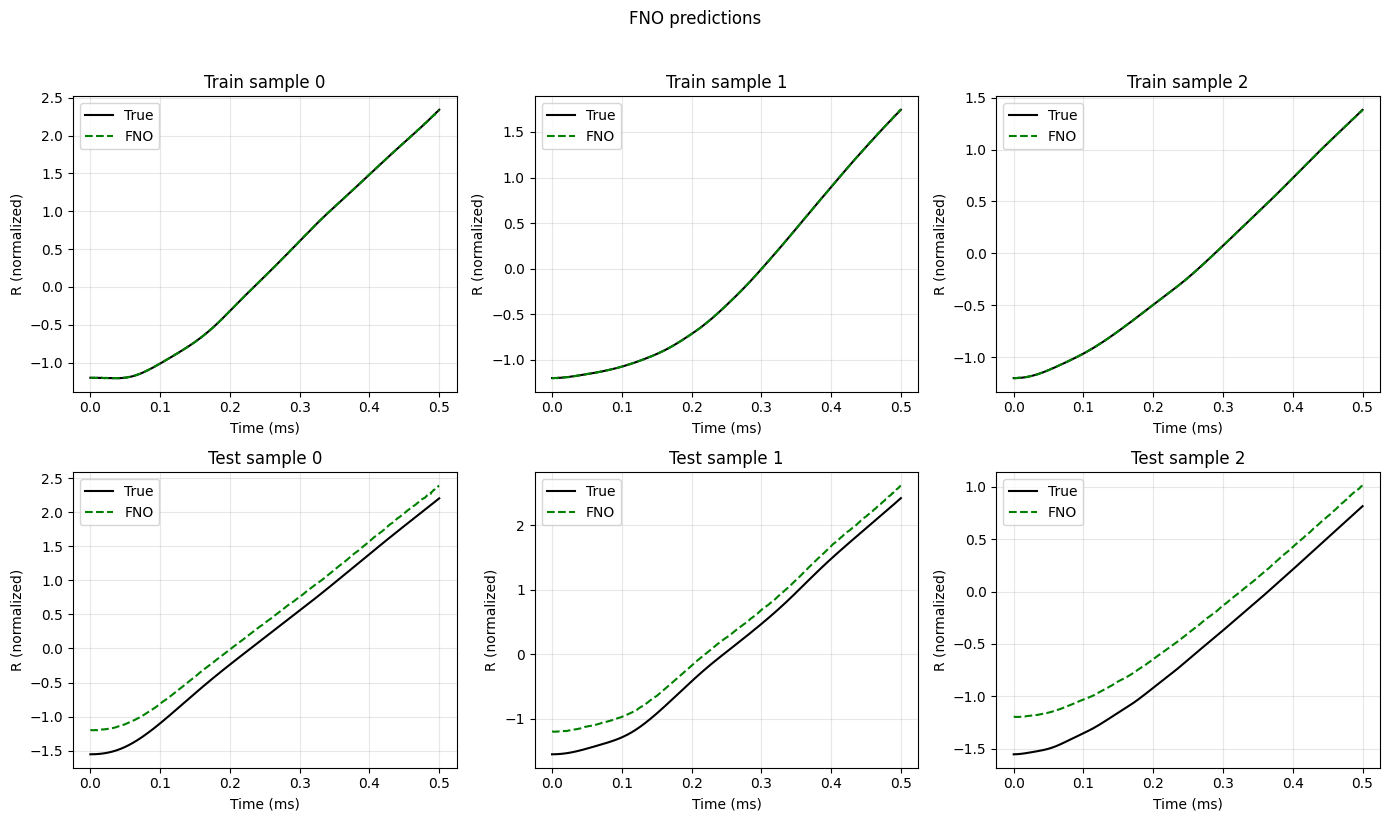

FNO - Train MSE: 1.2501e-06, Test MSE: 7.2540e-02


In [20]:
model_fno.eval()
with torch.no_grad():
    fno_pred_train = model_fno(torch.tensor(Xf_fno_tr, dtype=torch.float32).to(device)).cpu().numpy()
    fno_pred_test  = model_fno(torch.tensor(Xf_fno_te, dtype=torch.float32).to(device)).cpu().numpy()

fno_train_mse = np.mean((fno_pred_train - y_fno_tr)**2)
fno_test_mse  = np.mean((fno_pred_test - y_fno_te)**2)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
t_plot = np.linspace(0, 5e-4, N_fno) * 1e3

for i in range(3):
    axes[0, i].plot(t_plot, y_fno_tr[i], 'k-', label='True', linewidth=1.5)
    axes[0, i].plot(t_plot, fno_pred_train[i], 'g--', label='FNO', linewidth=1.5)
    axes[0, i].set_title(f'Train sample {i}')
    axes[0, i].set_xlabel('Time (ms)'); axes[0, i].set_ylabel('R (normalized)')
    axes[0, i].legend(); axes[0, i].grid(True, alpha=0.3)

for i in range(3):
    axes[1, i].plot(t_plot, y_fno_te[i], 'k-', label='True', linewidth=1.5)
    axes[1, i].plot(t_plot, fno_pred_test[i], 'g--', label='FNO', linewidth=1.5)
    axes[1, i].set_title(f'Test sample {i}')
    axes[1, i].set_xlabel('Time (ms)'); axes[1, i].set_ylabel('R (normalized)')
    axes[1, i].legend(); axes[1, i].grid(True, alpha=0.3)

plt.suptitle('FNO predictions', y=1.02)
plt.tight_layout()
plt.show()

print(f"FNO - Train MSE: {fno_train_mse:.4e}, Test MSE: {fno_test_mse:.4e}")

### Final comparison: DeepONet vs RNN vs FNO

Let's put all three models side by side on the same test samples to see how they compare visually and quantitatively.

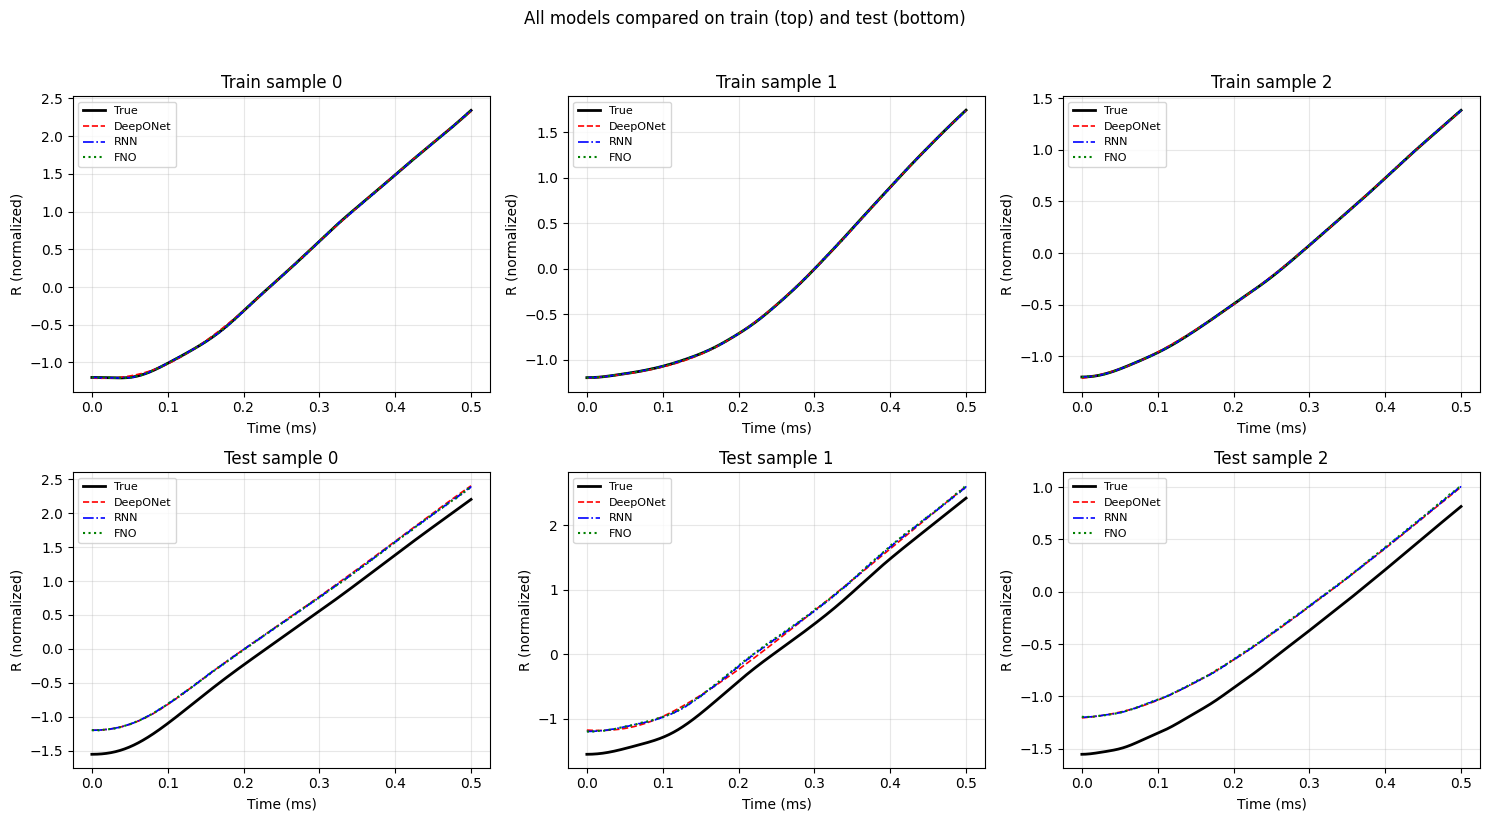

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
t_plot = np.linspace(0, 5e-4, npoints_output) * 1e3

for i in range(3):
    # Training samples
    axes[0, i].plot(t_plot, y_train[i], 'k-', label='True', linewidth=2)
    axes[0, i].plot(t_plot, pred_train[i], 'r--', label='DeepONet', linewidth=1.2)
    axes[0, i].plot(t_plot, rnn_pred_train[i], 'b-.', label='RNN', linewidth=1.2)
    axes[0, i].plot(t_plot, fno_pred_train[i], 'g:', label='FNO', linewidth=1.5)
    axes[0, i].set_title(f'Train sample {i}')
    axes[0, i].set_xlabel('Time (ms)'); axes[0, i].set_ylabel('R (normalized)')
    axes[0, i].legend(fontsize=8); axes[0, i].grid(True, alpha=0.3)

for i in range(3):
    # Test samples
    axes[1, i].plot(t_plot, y_test[i], 'k-', label='True', linewidth=2)
    axes[1, i].plot(t_plot, pred_test[i], 'r--', label='DeepONet', linewidth=1.2)
    axes[1, i].plot(t_plot, rnn_pred_test[i], 'b-.', label='RNN', linewidth=1.2)
    axes[1, i].plot(t_plot, fno_pred_test[i], 'g:', label='FNO', linewidth=1.5)
    axes[1, i].set_title(f'Test sample {i}')
    axes[1, i].set_xlabel('Time (ms)'); axes[1, i].set_ylabel('R (normalized)')
    axes[1, i].legend(fontsize=8); axes[1, i].grid(True, alpha=0.3)

plt.suptitle('All models compared on train (top) and test (bottom)', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# Summary table
don_train = np.mean((pred_train - y_train)**2)
don_test  = np.mean((pred_test - y_test)**2)
don_rel   = np.mean(np.abs(pred_test - y_test)) / np.mean(np.abs(y_test))

rnn_rel = np.mean(np.abs(rnn_pred_test - y_te_rnn)) / np.mean(np.abs(y_te_rnn))
fno_rel = np.mean(np.abs(fno_pred_test - y_fno_te)) / np.mean(np.abs(y_fno_te))

don_params = sum(p.numel() for p in model_don.parameters())
rnn_params = sum(p.numel() for p in model_rnn.parameters())
fno_params = sum(p.numel() for p in model_fno.parameters())

print(f"{'Model':<12} {'Params':>10} {'Train MSE':>12} {'Test MSE':>12} {'Test Rel.Err':>14}")
print(f"{'='*60}")
print(f"{'DeepONet':<12} {don_params:>10,} {don_train:>12.2e} {don_test:>12.2e} {don_rel:>14.4f}")
print(f"{'RNN (GRU)':<12} {rnn_params:>10,} {rnn_train_mse:>12.2e} {rnn_test_mse:>12.2e} {rnn_rel:>14.4f}")
print(f"{'FNO':<12} {fno_params:>10,} {fno_train_mse:>12.2e} {fno_test_mse:>12.2e} {fno_rel:>14.4f}")

Model            Params    Train MSE     Test MSE   Test Rel.Err
DeepONet        141,569     3.24e-05     6.71e-02         0.2788
RNN (GRU)       149,505     2.09e-05     6.74e-02         0.2796
FNO             549,505     1.25e-06     7.25e-02         0.2829


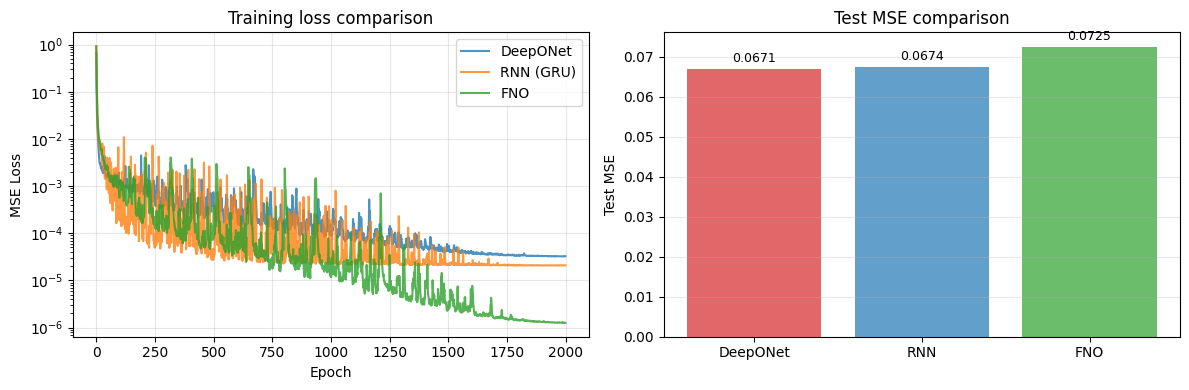

In [23]:
# Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(don_history['train_loss'], label='DeepONet', alpha=0.8)
axes[0].plot(rnn_history['train_loss'], label='RNN (GRU)', alpha=0.8)
axes[0].plot(fno_history['train_loss'], label='FNO', alpha=0.8)
axes[0].set_yscale('log'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training loss comparison')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Bar chart of test MSE
models = ['DeepONet', 'RNN', 'FNO']
test_mses = [don_test, rnn_test_mse, fno_test_mse]
colors = ['tab:red', 'tab:blue', 'tab:green']
bars = axes[1].bar(models, test_mses, color=colors, alpha=0.7)
axes[1].set_ylabel('Test MSE'); axes[1].set_title('Test MSE comparison')
for bar, val in zip(bars, test_mses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Conclusions

All three architectures fit the training data well but struggle with the test set in roughly the same way. The FNO achieves the lowest training error by a wide margin (1.25e-6 vs ~2-3e-5 for the others), which speaks to the expressiveness of spectral convolutions for smooth temporal signals. However, having 4x more parameters and a stronger fit to the training distribution doesn't help on test data from a different physical regime.

The DeepONet has the cleanest architecture for this problem: the branch/trunk decomposition explicitly separates "what is the input function?" from "where do I want to evaluate the output?", which is exactly the structure of our operator learning task. The RNN performs comparably with a similar parameter count, but its sequential nature makes it slower to train. The FNO is the most expressive on training data but also the most expensive.

The test error of ~0.067-0.073 across all models reflects a fundamental challenge: the test set uses $R_0 = 0.8\text{mm}$ while training uses $R_0 = 1\text{mm}$. The pressure-to-radius mapping depends on the initial condition, which none of these models receive as an explicit input. To improve test performance, one would need to either include $R_0$ as a conditioning input or train on a mixture of initial conditions.